Libraries & Config

In [9]:
# ==========================
# Libraries & Config
# ==========================
import os, random, time
from glob import glob

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# ==========================
# Config
# ==========================
class CFG:
    DATASET_PATH = "/kaggle/input/processed-rice-varieties-of-bd/PRBD Microscopic Image of Different Processed Rice/Original_Images"
    IMG_EXTS = (".png",".jpg",".jpeg",".bmp")
    IMG_SIZE = 128  # Increased for richer features

    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS = 2

    # MAE Pretrain
    MAE_BATCH = 32
    MAE_EPOCHS = 120
    MAE_LR = 3e-4
    MASK_RATIO = 0.75

    PATCH_SIZE = 4
    EMBED_DIM = 256
    ENC_LAYERS = 8
    DEC_LAYERS = 2
    NHEAD = 8

    OUT_DIR = "/kaggle/working/mae_out"

os.makedirs(CFG.OUT_DIR, exist_ok=True)

def set_seed(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device(CFG.DEVICE)
print("Device =", device)


Device = cuda


Dataset / DataFrame

In [10]:
# ---------------- Class Map ----------------
CLASS_MAP = {
    "Aush": 0, "Beroi": 1, "BR-28": 2, "BR-29": 3,
    "Chinigura": 4, "Ghee Bhog": 5, "Katari Najir": 6,
    "Katari Siddho": 7, "Miniket": 8, "Swarna": 9
}

# ---------------- Create DataFrame ----------------
rows = []
for cls, lbl in CLASS_MAP.items():
    folder = os.path.join(CFG.DATASET_PATH, cls)
    for img in glob(folder + "/*"):
        if img.lower().endswith(CFG.IMG_EXTS):
            rows.append({"image": img, "label": lbl, "cls": cls})

df_all = pd.DataFrame(rows)
print("Class distribution:\n", df_all["cls"].value_counts())



Class distribution:
 cls
Aush             200
Beroi            200
BR-28            200
BR-29            200
Chinigura        200
Ghee Bhog        200
Katari Najir     200
Katari Siddho    200
Miniket          200
Swarna           200
Name: count, dtype: int64


Class wise split

In [11]:
# ==========================
train_dfs, val_dfs, test_dfs = [], [], []

for cls in CLASS_MAP.keys():          # Loop over each class
    cls_df = df_all[df_all["cls"] == cls]
    
    # 20% for test
    train_val, test = train_test_split(cls_df, test_size=0.2, random_state=CFG.SEED, shuffle=True)
    
    # 10% of train_val for validation
    train, val = train_test_split(train_val, test_size=0.1, random_state=CFG.SEED, shuffle=True)

    train_dfs.append(train)
    val_dfs.append(val)
    test_dfs.append(test)

train_df = pd.concat(train_dfs).reset_index(drop=True)
val_df   = pd.concat(val_dfs).reset_index(drop=True)
test_df  = pd.concat(test_dfs).reset_index(drop=True)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))
print("Train class distribution:\n", train_df['cls'].value_counts())
print("Val class distribution:\n", val_df['cls'].value_counts())
print("Test class distribution:\n", test_df['cls'].value_counts())


Train: 1440  Val: 160  Test: 400
Train class distribution:
 cls
Aush             144
Beroi            144
BR-28            144
BR-29            144
Chinigura        144
Ghee Bhog        144
Katari Najir     144
Katari Siddho    144
Miniket          144
Swarna           144
Name: count, dtype: int64
Val class distribution:
 cls
Aush             16
Beroi            16
BR-28            16
BR-29            16
Chinigura        16
Ghee Bhog        16
Katari Najir     16
Katari Siddho    16
Miniket          16
Swarna           16
Name: count, dtype: int64
Test class distribution:
 cls
Aush             40
Beroi            40
BR-28            40
BR-29            40
Chinigura        40
Ghee Bhog        40
Katari Najir     40
Katari Siddho    40
Miniket          40
Swarna           40
Name: count, dtype: int64


Unlabeled Dataset for MAE

In [12]:
rows = []
for cls in os.listdir(CFG.DATASET_PATH):
    folder = os.path.join(CFG.DATASET_PATH, cls)
    if not os.path.isdir(folder):
        continue
    for img in glob(folder+"/*"):
        if img.lower().endswith(CFG.IMG_EXTS):
            rows.append({"image": img})

df_unlabeled = pd.DataFrame(rows)
print("Unlabeled:",len(df_unlabeled))



Unlabeled: 2000


Patch Embedding + MAE with [CLS] token + PreNorm

In [13]:
def patchify(x, p):
    B,C,H,W = x.shape
    assert H % p == 0 and W % p == 0
    x = x.reshape(B,C,H//p,p,W//p,p)
    x = x.permute(0,2,4,1,3,5).contiguous()
    return x.reshape(B, -1, C*p*p)

def random_masking(x, mask_ratio):
    B,N,D = x.shape
    len_keep = int(N*(1-mask_ratio))
    noise = torch.rand(B,N,device=x.device)
    ids_shuffle = noise.argsort(1)
    ids_restore = ids_shuffle.argsort(1)
    ids_keep = ids_shuffle[:,:len_keep]

    x_vis = torch.gather(x,1,ids_keep.unsqueeze(-1).expand(-1,-1,D))
    mask = torch.ones(B,N,device=x.device)
    mask[:,:len_keep] = 0
    mask = torch.gather(mask,1,ids_restore)
    return x_vis, mask.bool(), ids_keep, ids_restore

class PatchEmbed(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, CFG.EMBED_DIM, CFG.PATCH_SIZE, CFG.PATCH_SIZE)
    def forward(self,x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, dim, nhead):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, nhead, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )
    def forward(self,x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class MAE(nn.Module):
    def __init__(self):
        super().__init__()
        N = (CFG.IMG_SIZE//CFG.PATCH_SIZE)**2

        self.patch = PatchEmbed()
        self.pos = nn.Parameter(torch.zeros(1, N+1, CFG.EMBED_DIM))  # +1 CLS token
        self.cls_token = nn.Parameter(torch.zeros(1,1,CFG.EMBED_DIM))

        self.encoder = nn.Sequential(*[TransformerBlock(CFG.EMBED_DIM, CFG.NHEAD) for _ in range(CFG.ENC_LAYERS)])
        self.decoder = nn.Sequential(*[TransformerBlock(CFG.EMBED_DIM, CFG.NHEAD) for _ in range(CFG.DEC_LAYERS)])

        self.mask_token = nn.Parameter(torch.zeros(1,1,CFG.EMBED_DIM))
        self.head = nn.Linear(CFG.EMBED_DIM, CFG.PATCH_SIZE*CFG.PATCH_SIZE*3)

        nn.init.trunc_normal_(self.pos,std=0.02)
        nn.init.trunc_normal_(self.cls_token,std=0.02)

    def forward(self,x):
        B = x.size(0)
        patches = self.patch(x)
        x_vis, mask, ids_keep, ids_restore = random_masking(patches, CFG.MASK_RATIO)

        cls_tokens = self.cls_token.expand(B,-1,-1)
        pos = self.pos.expand(B,-1,-1)
        x_vis = torch.cat([cls_tokens, x_vis], dim=1)

        pos_vis = torch.gather(pos[:,1:,:].expand(B,-1,-1),1, ids_keep.unsqueeze(-1).expand(-1,-1,CFG.EMBED_DIM))
        x_vis[:,1:,:] = x_vis[:,1:,:] + pos_vis
        x_vis[:,0,:] = x_vis[:,0,:] + pos[:,0,:]

        encoded = self.encoder(x_vis)

        N = patches.size(1)
        dec = torch.zeros(B,N,CFG.EMBED_DIM,device=x.device)
        dec = dec.scatter(1, ids_keep.unsqueeze(-1).expand(-1,-1,CFG.EMBED_DIM), encoded[:,1:,:])
        mask_token = self.mask_token.expand(B,N,-1)
        dec = torch.where(mask.unsqueeze(-1), mask_token, dec)
        dec = dec + pos[:,1:,:]
        dec = self.decoder(dec)

        pred = self.head(dec)
        return pred, mask, encoded[:,0,:]  # Return CLS embedding




Dataset with Augmentation

In [14]:
class MAEDatasetAug(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.tf = transforms.Compose([
            transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(0.1,0.1,0.1,0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    def __getitem__(self, idx):
        path = self.df.loc[idx, "image"]
        try:
            img = Image.open(path).convert("RGB")
        except:
            alt = np.random.randint(0, len(self.df))
            img = Image.open(self.df.loc[alt, "image"]).convert("RGB")
        return self.tf(img)
    def __len__(self):
        return len(self.df)

mae_loader = DataLoader(
    MAEDatasetAug(df_unlabeled),
    batch_size=CFG.MAE_BATCH,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)


Training Loop

In [15]:
model = MAE().to(device)
nn.init.trunc_normal_(model.mask_token, std=0.02)

opt = torch.optim.AdamW(model.parameters(), lr=CFG.MAE_LR, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG.MAE_EPOCHS)

def mae_loss(x, pred, mask):
    gt = patchify(x, CFG.PATCH_SIZE)
    return F.mse_loss(pred[mask], gt[mask])

from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()
loss_history = []

for epoch in range(1, CFG.MAE_EPOCHS+1):
    model.train()
    total = 0
    for imgs in tqdm(mae_loader, desc=f"Epoch {epoch}"):
        imgs = imgs.to(device)
        with autocast():
            pred, mask, _ = model(imgs)
            loss = mae_loss(imgs, pred, mask)

        opt.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        total += loss.item()

    total /= len(mae_loader)
    loss_history.append(total)
    print(f"Epoch {epoch} — Loss: {total:.5f}")
    scheduler.step()


/tmp/ipykernel_47/1915147351.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_47/1915147351.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1: 100%|██████████| 63/63 [00:21<00:00,  2.94it/s]


Epoch 1 — Loss: 0.98182


Epoch 2: 100%|██████████| 63/63 [00:20<00:00,  3.15it/s]


Epoch 2 — Loss: 0.62526


Epoch 3: 100%|██████████| 63/63 [00:20<00:00,  3.14it/s]


...

Epoch 118 — Loss: 0.10059


Epoch 119: 100%|██████████| 63/63 [00:20<00:00,  3.15it/s]


Epoch 119 — Loss: 0.09868


Epoch 120: 100%|██████████| 63/63 [00:20<00:00,  3.15it/s]

Epoch 120 — Loss: 0.09985


Loss Curve

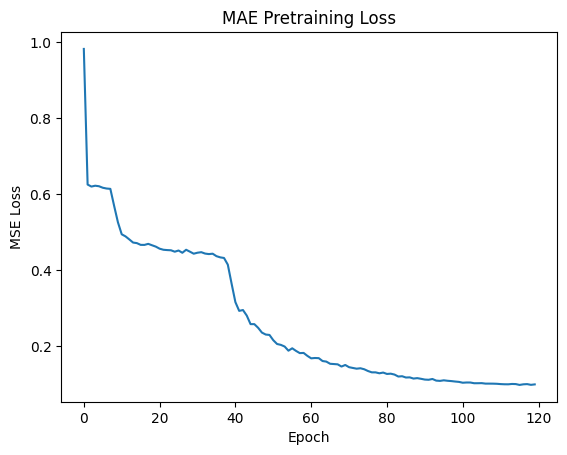

In [16]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MAE Pretraining Loss")
plt.show()


EncoderOnly Wrapper for Downstream

In [17]:
class EncoderOnly(nn.Module):
    def __init__(self, mae):
        super().__init__()
        self.patch = mae.patch
        self.pos = mae.pos
        self.cls_token = mae.cls_token
        self.encoder = mae.encoder

    def forward(self,x):
        p = self.patch(x)
        B = p.size(0)
        cls_tokens = self.cls_token.expand(B,-1,-1)
        x = torch.cat([cls_tokens, p], dim=1)
        x = x + self.pos
        f = self.encoder(x)
        cls_feat = f[:,0,:]
        return F.normalize(cls_feat, dim=1)  # normalized for SVM / MLP

enc = EncoderOnly(model).to("cpu")
torch.save(enc.state_dict(), f"{CFG.OUT_DIR}/encoder_cls_frozen.pth")
print("Saved frozen encoder with CLS token embedding!")


Saved frozen encoder with CLS token embedding!


Plot Loss

In [18]:
print("Searching in:", CFG.OUT_DIR)
for root, dirs, files in os.walk(CFG.OUT_DIR):
    for f in files:
        if "encoder" in f:
            print("Found:", os.path.join(root, f))


Searching in: /kaggle/working/mae_out
Found: /kaggle/working/mae_out/encoder_cls_frozen.pth


Extracting features: 100%|██████████| 45/45 [13:04<00:00, 17.44s/it]


Features shape: (1440, 256)


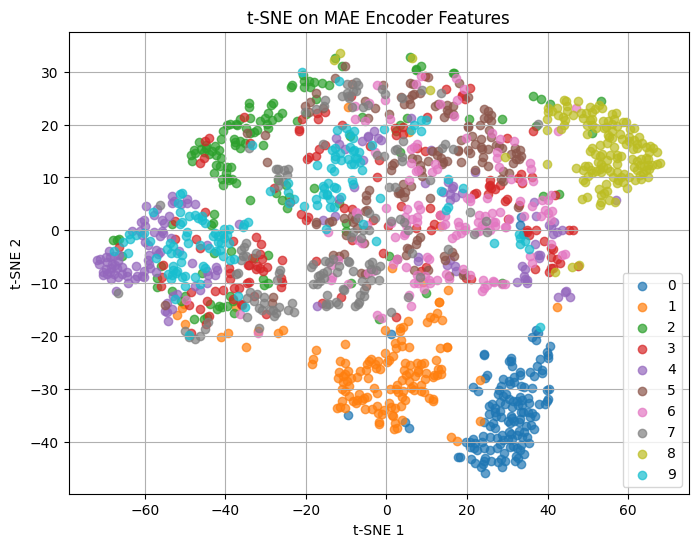

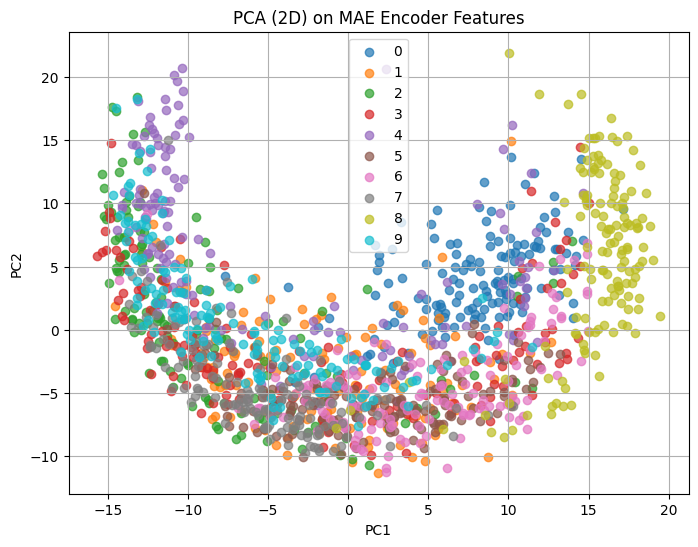

Silhouette Score (on normalized features): 0.0341


In [19]:
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# =========================
# Feature Dataset
# =========================
class FeatureDataset(Dataset):
    def __init__(self, df, img_size=CFG.IMG_SIZE):
        self.df = df.reset_index(drop=True)
        self.tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "image"]).convert("RGB")
        label = self.df.loc[idx, "label"]
        return self.tf(img), label
    def __len__(self):
        return len(self.df)

# =========================
# DataLoader
# =========================
feat_dataset = FeatureDataset(train_df)
feat_loader = DataLoader(feat_dataset, batch_size=CFG.MAE_BATCH, shuffle=False, num_workers=CFG.NUM_WORKERS)

# =========================
# Extract Features
# =========================
enc.eval()  # Make sure encoder is in eval mode
device = torch.device("cpu")  # Use CPU for extraction (t-SNE is CPU-bound)
all_features = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(feat_loader, desc="Extracting features"):
        imgs = imgs.to(device)
        feats = enc(imgs)  # (B, embed_dim)
        all_features.append(feats.cpu().numpy())
        all_labels.append(labels.numpy())

all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print("Features shape:", all_features.shape)

# =========================
# Standardize features
# =========================
scaler = StandardScaler()
all_features_scaled = scaler.fit_transform(all_features)

# =========================
# PCA (optional pre-reduction)
# =========================
pca_50 = PCA(n_components=50, random_state=42)
features_pca50 = pca_50.fit_transform(all_features_scaled)

# =========================
# t-SNE
# =========================
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=2000, init='pca')
features_tsne = tsne.fit_transform(features_pca50)

# =========================
# t-SNE Plot
# =========================
plt.figure(figsize=(8,6))
for lbl in np.unique(all_labels):
    idxs = all_labels == lbl
    plt.scatter(features_tsne[idxs,0], features_tsne[idxs,1], label=str(lbl), alpha=0.7)
plt.legend()
plt.title("t-SNE on MAE Encoder Features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.show()

# =========================
# PCA 2D Visualization
# =========================
pca_2 = PCA(n_components=2, random_state=42)
features_pca2 = pca_2.fit_transform(all_features_scaled)

plt.figure(figsize=(8,6))
for lbl in np.unique(all_labels):
    idxs = all_labels == lbl
    plt.scatter(features_pca2[idxs,0], features_pca2[idxs,1], label=str(lbl), alpha=0.7)
plt.legend()
plt.title("PCA (2D) on MAE Encoder Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# =========================
# Silhouette Score
# =========================
sil_score = silhouette_score(all_features_scaled, all_labels)
print(f"Silhouette Score (on normalized features): {sil_score:.4f}")


Linear Probe

In [38]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import transforms
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from tqdm import tqdm
import numpy as np
from PIL import Image

device = torch.device(CFG.DEVICE)
NUM_CLASSES = len(CLASS_MAP)
LP_BATCH = 32
LP_EPOCHS = 120
LP_LR = 1e-3

# -------------------------------
# Feature Extraction Dataset
# -------------------------------
class FeatureDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.tf = transforms.Compose([
            transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "image"]).convert("RGB")
        label = self.df.loc[idx, "label"]
        return self.tf(img), label
    def __len__(self):
        return len(self.df)

# -------------------------------
# Feature Extraction Function
# -------------------------------
def extract_features(loader, encoder):
    encoder.eval()
    feats, labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Extracting features"):
            imgs = imgs.to(device)
            f = encoder(imgs)
            feats.append(f.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(labels, axis=0)

# -------------------------------
# Load Frozen Encoder
# -------------------------------
encoder_only = EncoderOnly(model).to(device)
encoder_only.load_state_dict(torch.load(f"{CFG.OUT_DIR}/encoder_cls_frozen.pth"))
encoder_only.eval()

# -------------------------------
# Extract features for train/val/test
# -------------------------------
train_loader_f = DataLoader(FeatureDataset(train_df), batch_size=LP_BATCH, shuffle=False)
val_loader_f   = DataLoader(FeatureDataset(val_df), batch_size=LP_BATCH, shuffle=False)
test_loader_f  = DataLoader(FeatureDataset(test_df), batch_size=LP_BATCH, shuffle=False)

X_train, y_train = extract_features(train_loader_f, encoder_only)
X_val, y_val     = extract_features(val_loader_f, encoder_only)
X_test, y_test   = extract_features(test_loader_f, encoder_only)

# -------------------------------
# Standardize Features
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# -------------------------------
# Create Torch Datasets
# -------------------------------
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
val_ds   = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                         torch.tensor(y_val, dtype=torch.long))
test_ds  = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                         torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=LP_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=LP_BATCH, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=LP_BATCH, shuffle=False)

# -------------------------------
# Linear Probe Model
# -------------------------------
class LinearProbe(nn.Module):
    def __init__(self, input_dim=X_train.shape[1], num_classes=NUM_CLASSES):
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.fc(x)

lp_model = LinearProbe().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lp_model.parameters(), lr=LP_LR)

# -------------------------------
# Training Loop (tqdm + epoch summary)
# -------------------------------
best_val_acc = 0.0
for epoch in range(1, LP_EPOCHS+1):
    lp_model.train()
    total_correct, total_samples = 0, 0
    running_loss = 0.0
    
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{LP_EPOCHS}", leave=False)
    for imgs, labels in batch_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = lp_model(imgs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        running_loss += loss.item() * labels.size(0)
        
        batch_bar.set_postfix({'batch_loss': f"{loss.item():.5f}"})
    
    train_acc = total_correct / total_samples
    avg_loss = running_loss / total_samples

    # Validation
    lp_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = lp_model(imgs).argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(lp_model.state_dict(), f"{CFG.OUT_DIR}/linear_probe_best.pth")
    
    # Epoch summary
    print(f"Epoch {epoch:03d} — Loss: {avg_loss:.5f} | Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

# -------------------------------
# Test Metrics
# -------------------------------
lp_model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = lp_model(imgs).argmax(dim=1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print("\nLinear Probe Test Metrics:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=list(CLASS_MAP.keys())))


Extracting features: 100%|██████████| 13/13 [00:08<00:00,  1.46it/s]


Epoch 001 — Loss: 1.51385 | Train Acc=0.5069, Val Acc=0.6562


Epoch 002 — Loss: 0.96198 | Train Acc=0.7153, Val Acc=0.7000


Epoch 003 — Loss: 0.81701 | Train Acc=0.7715, Val Acc=0.7500


Epoch 004 — Loss: 0.74209 | Train Acc=0.7937, Val Acc=0.7625


...

Epoch 116 — Loss: 0.23556 | Train Acc=0.9361, Val Acc=0.8438


Epoch 117 — Loss: 0.23397 | Train Acc=0.9368, Val Acc=0.8500


Epoch 118 — Loss: 0.23428 | Train Acc=0.9333, Val Acc=0.8375


Epoch 119 — Loss: 0.23538 | Train Acc=0.9333, Val Acc=0.8375


Epoch 120 — Loss: 0.23426 | Train Acc=0.9333, Val Acc=0.8375

Linear Probe Test Metrics:
Accuracy: 0.9
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        Beroi       0.97      0.97      0.97        40
        BR-28       0.97      0.78      0.86        40
        BR-29       0.80      0.90      0.85        40
    Chinigura       0.93      1.00      0.96        40
    Ghee Bhog       0.84      0.78      0.81        40
 Katari Najir       0.75      0.75      0.75        40
Katari Siddho       0.88      0.88      0.88        40
      Miniket       1.00      1.00      1.00        40
       Swarna       0.88      0.95      0.92        40

     accuracy                           0.90       400
    macro avg       0.90      0.90      0.90       400
 weighted avg       0.90      0.90      0.90       400



MLP 

In [39]:
# ===============================
# STRONGER ENHANCED MLP ON MAE FEATURES
# ===============================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
from tqdm import tqdm

device = torch.device(CFG.DEVICE)
NUM_CLASSES = len(CLASS_MAP)
MLP_BATCH = 32
MLP_EPOCHS = 120
MLP_LR = 5e-4  # slightly lower LR
HIDDEN1 = 2048
HIDDEN2 = 1024
HIDDEN3 = 512

# -------------------------------
# Torch Datasets
# -------------------------------
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
val_ds   = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                         torch.tensor(y_val, dtype=torch.long))
test_ds  = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                         torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=MLP_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=MLP_BATCH, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=MLP_BATCH, shuffle=False)

# -------------------------------
# Stronger Enhanced MLP Model
# -------------------------------
class StrongerMLP(nn.Module):
    def __init__(self, input_dim=X_train.shape[1], num_classes=NUM_CLASSES):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, HIDDEN1),
            nn.BatchNorm1d(HIDDEN1),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.4),
            
            nn.Linear(HIDDEN1, HIDDEN2),
            nn.BatchNorm1d(HIDDEN2),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            
            nn.Linear(HIDDEN2, HIDDEN3),
            nn.BatchNorm1d(HIDDEN3),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(HIDDEN3, num_classes)
        )
    def forward(self, x):
        return self.mlp(x)

mlp_model = StrongerMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=MLP_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MLP_EPOCHS)

# -------------------------------
# Training Loop
# -------------------------------
best_val_acc = 0.0
for epoch in range(1, MLP_EPOCHS+1):
    mlp_model.train()
    total_correct, total_samples = 0, 0
    total_loss = 0.0
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{MLP_EPOCHS} Batches", leave=False)
    
    for imgs, labels in batch_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = mlp_model(imgs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mlp_model.parameters(), 1.0)
        optimizer.step()
        
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        total_loss += loss.item() * labels.size(0)
        batch_bar.set_postfix({'batch_loss': f"{loss.item():.4f}"})
    
    train_acc = total_correct / total_samples
    train_loss = total_loss / total_samples

    # Validation
    mlp_model.eval()
    val_correct, val_total, val_loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = mlp_model(imgs)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_loss_sum += loss.item() * labels.size(0)
    val_acc = val_correct / val_total
    val_loss = val_loss_sum / val_total

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(mlp_model.state_dict(), f"{CFG.OUT_DIR}/stronger_mlp_best.pth")

    scheduler.step()

    # Print epoch metrics
    print(f"Epoch {epoch:03d}: Train Loss={train_loss:.5f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.5f}, Val Acc={val_acc:.4f}")

# -------------------------------
# Test Metrics
# -------------------------------
mlp_model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = mlp_model(imgs).argmax(dim=1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print("\nStronger Enhanced MLP Test Metrics:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=list(CLASS_MAP.keys())))


Epoch 001: Train Loss=1.02780, Train Acc=0.6632, Val Loss=0.78875, Val Acc=0.7688


Epoch 002: Train Loss=0.67395, Train Acc=0.7757, Val Loss=0.61592, Val Acc=0.7937


Epoch 003: Train Loss=0.59065, Train Acc=0.7944, Val Loss=0.59493, Val Acc=0.7937


Epoch 004: Train Loss=0.55574, Train Acc=0.8014, Val Loss=0.61012, Val Acc=0.8063


Epoch 005: Train Loss=0.48213, Train Acc=0.8326, Val Loss=0.65668, Val Acc=0.7812


...

Epoch 116: Train Loss=0.02921, Train Acc=0.9889, Val Loss=0.54517, Val Acc=0.8562


Epoch 117: Train Loss=0.01918, Train Acc=0.9965, Val Loss=0.53424, Val Acc=0.8625


Epoch 118: Train Loss=0.03048, Train Acc=0.9889, Val Loss=0.52083, Val Acc=0.8562


Epoch 119: Train Loss=0.02987, Train Acc=0.9910, Val Loss=0.53404, Val Acc=0.8625


Epoch 120: Train Loss=0.03198, Train Acc=0.9896, Val Loss=0.53164, Val Acc=0.8562

Stronger Enhanced MLP Test Metrics:
Accuracy: 0.8875
               precision    recall  f1-score   support

         Aush       0.97      0.97      0.97        40
        Beroi       0.95      0.95      0.95        40
        BR-28       0.80      0.80      0.80        40
        BR-29       0.80      0.70      0.75        40
    Chinigura       0.93      1.00      0.96        40
    Ghee Bhog       0.86      0.78      0.82        40
 Katari Najir       0.85      0.85      0.85        40
Katari Siddho       0.84      0.93      0.88        40
      Miniket       0.97      0.97      0.97        40
       Swarna       0.88      0.93      0.90        40

     accuracy                           0.89       400
    macro avg       0.89      0.89      0.89       400
 weighted avg       0.89      0.89      0.89       400



SVM

In [31]:
# ===============================
# SVM with PCA Preprocessing for Better Accuracy
# ===============================
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

# -------------------------------
# PCA pre-reduction to 50 dims
# -------------------------------
pca = PCA(n_components=50, random_state=CFG.SEED)
X_pca_train = pca.fit_transform(X_train)
X_pca_test  = pca.transform(X_test)

# -------------------------------
# Hyperparameter Grid for SVM
# -------------------------------
param_grid = {
    'C': [1, 10, 50],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

svm_clf = GridSearchCV(SVC(random_state=CFG.SEED), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
svm_clf.fit(X_pca_train, y_train)

print("Best Hyperparameters:", svm_clf.best_params_)

# -------------------------------
# Test Predictions
# -------------------------------
y_pred_svm = svm_clf.predict(X_pca_test)

acc = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM Test Accuracy (with PCA + GridSearch): {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=list(CLASS_MAP.keys())))


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Hyperparameters: {'C': 50, 'gamma': 0.001, 'kernel': 'rbf'}

SVM Test Accuracy (with PCA + GridSearch): 0.8675
Classification Report:
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        Beroi       0.97      0.90      0.94        40
        BR-28       0.79      0.68      0.73        40
        BR-29       0.67      0.75      0.71        40
    Chinigura       0.95      1.00      0.98        40
    Ghee Bhog       0.89      0.78      0.83        40
 Katari Najir       0.70      0.78      0.74        40
Katari Siddho       0.80      0.88      0.83        40
      Miniket       1.00      0.97      0.99        40
       Swarna       0.95      0.95      0.95        40

     accuracy                           0.87       400
    macro avg       0.87      0.87      0.87       400
 weighted avg       0.87      0.87      0.87       400



Decision Tree

In [44]:
# ===============================
# DECISION TREE ON MAE FEATURES
# ===============================
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import joblib  # for saving the model

# -------------------------------
# Standardize Features
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------
# Optimized Decision Tree
# -------------------------------
dt_model = DecisionTreeClassifier(
    criterion='entropy',      # use information gain
    max_depth=25,             # control depth to avoid overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Fit on train
dt_model.fit(X_train_scaled, y_train)

# -------------------------------
# Validation
# -------------------------------
y_val_pred = dt_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Decision Tree Validation Accuracy: {val_acc:.4f}")

# -------------------------------
# Test Metrics
# -------------------------------
y_test_pred = dt_model.predict(X_test_scaled)
print("\nDecision Tree Test Metrics:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=list(CLASS_MAP.keys())))

# -------------------------------
# Save the model
# -------------------------------
joblib.dump(dt_model, f"{CFG.OUT_DIR}/decision_tree_mae.pkl")


Decision Tree Validation Accuracy: 0.5875

Decision Tree Test Metrics:
Accuracy: 0.65
               precision    recall  f1-score   support

         Aush       0.90      0.88      0.89        40
        Beroi       0.82      0.78      0.79        40
        BR-28       0.59      0.55      0.57        40
        BR-29       0.39      0.38      0.38        40
    Chinigura       0.69      0.93      0.79        40
    Ghee Bhog       0.71      0.62      0.67        40
 Katari Najir       0.38      0.42      0.40        40
Katari Siddho       0.48      0.53      0.50        40
      Miniket       0.87      0.85      0.86        40
       Swarna       0.74      0.57      0.65        40

     accuracy                           0.65       400
    macro avg       0.66      0.65      0.65       400
 weighted avg       0.66      0.65      0.65       400



['/kaggle/working/mae_out/decision_tree_mae.pkl']

Random forest

In [47]:
# ===============================
# RANDOM FOREST 
# ===============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import joblib
import numpy as np

# -------------------------------
# Combine train + val for final training
# -------------------------------
X_train_full = np.vstack([X_train_scaled, X_val_scaled])
y_train_full = np.hstack([y_train, y_val])

# -------------------------------
# Enhanced Random Forest
# -------------------------------
rf_model = RandomForestClassifier(
    n_estimators=1200,           # more trees
    max_depth=None,               # grow fully
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    criterion='entropy',
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

# -------------------------------
# Fit on full training data
# -------------------------------
rf_model.fit(X_train_full, y_train_full)

# -------------------------------
# Test Metrics
# -------------------------------
y_test_pred = rf_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Enhanced Random Forest Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_test_pred, target_names=list(CLASS_MAP.keys())))

# -------------------------------
# Save the model
# -------------------------------
joblib.dump(rf_model, f"{CFG.OUT_DIR}/enhanced_random_forest_mae.pkl")


Enhanced Random Forest Test Accuracy: 0.7800
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        Beroi       1.00      0.88      0.93        40
        BR-28       0.81      0.65      0.72        40
        BR-29       0.62      0.50      0.56        40
    Chinigura       0.88      0.93      0.90        40
    Ghee Bhog       0.72      0.78      0.75        40
 Katari Najir       0.57      0.57      0.57        40
Katari Siddho       0.58      0.70      0.64        40
      Miniket       0.91      0.97      0.94        40
       Swarna       0.73      0.82      0.78        40

     accuracy                           0.78       400
    macro avg       0.78      0.78      0.78       400
 weighted avg       0.78      0.78      0.78       400



['/kaggle/working/mae_out/enhanced_random_forest_mae.pkl']

In [49]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_full = np.vstack([X_train_scaled, X_val_scaled])
y_full = np.hstack([y_train, y_val])

rf = RandomForestClassifier(
    n_estimators=1200,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.9,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)

rf.fit(X_full, y_full)
xgb.fit(X_full, y_full)
svm.fit(X_full, y_full)

rf_pred_train = rf.predict_proba(X_full)
xgb_pred_train = xgb.predict_proba(X_full)
svm_pred_train = svm.predict_proba(X_full)

meta_X_train = np.hstack([rf_pred_train, xgb_pred_train, svm_pred_train])

meta_model = LogisticRegression(max_iter=500, multi_class='multinomial')
meta_model.fit(meta_X_train, y_full)

rf_pred_test = rf.predict_proba(X_test_scaled)
xgb_pred_test = xgb.predict_proba(X_test_scaled)
svm_pred_test = svm.predict_proba(X_test_scaled)

meta_X_test = np.hstack([rf_pred_test, xgb_pred_test, svm_pred_test])

y_test_pred = meta_model.predict(meta_X_test)

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=list(CLASS_MAP.keys())))

joblib.dump(rf, f"{CFG.OUT_DIR}/stack_rf.pkl")
joblib.dump(xgb, f"{CFG.OUT_DIR}/stack_xgb.pkl")
joblib.dump(svm, f"{CFG.OUT_DIR}/stack_svm.pkl")
joblib.dump(meta_model, f"{CFG.OUT_DIR}/stack_meta.pkl")
joblib.dump(scaler, f"{CFG.OUT_DIR}/stack_scaler.pkl")


Accuracy: 0.82
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        Beroi       0.97      0.88      0.92        40
        BR-28       0.75      0.68      0.71        40
        BR-29       0.61      0.62      0.62        40
    Chinigura       0.95      0.97      0.96        40
    Ghee Bhog       0.77      0.75      0.76        40
 Katari Najir       0.66      0.68      0.67        40
Katari Siddho       0.78      0.78      0.78        40
      Miniket       0.93      1.00      0.96        40
       Swarna       0.79      0.85      0.82        40

     accuracy                           0.82       400
    macro avg       0.82      0.82      0.82       400
 weighted avg       0.82      0.82      0.82       400



['/kaggle/working/mae_out/stack_scaler.pkl']

Full Fine Tuning

In [54]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
from timm import create_model
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

DATA_DIR = "/kaggle/input/processed-rice-varieties-of-bd/PRBD Microscopic Image of Different Processed Rice/Original_Images"

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_ds = datasets.ImageFolder(DATA_DIR, transform=train_tfms)

total_len = len(full_ds)
val_len = int(0.10 * total_len)
test_len = int(0.10 * total_len)
train_len = total_len - val_len - test_len

train_ds, val_ds, test_ds = random_split(full_ds, [train_len, val_len, test_len])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

num_classes = len(full_ds.classes)

model = create_model("vit_base_patch16_224.mae", pretrained=True)
model.head = nn.Linear(model.num_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120, eta_min=1e-6)

best_val_acc = 0

for epoch in range(1, 121):

    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    
    progress = tqdm(train_loader, desc=f"Epoch {epoch}", ncols=110)
    
    for imgs, labels in progress:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        train_acc = train_correct / train_total

        progress.set_postfix({
            "loss": f"{running_loss/len(progress):.4f}",
            "acc": f"{train_acc:.4f}"
        })

    train_acc_final = train_correct / train_total
    print(f"Epoch {epoch} — Train Acc: {train_acc_final:.4f}")

    # Validation
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Validation Acc: {val_acc:.4f}\n")

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "mae_finetune_best.pth")

# Test accuracy
model.load_state_dict(torch.load("mae_finetune_best.pth"))
model.eval()

correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("\nFinal Test Accuracy:", correct / total)


Epoch 1: 100%|███████████████████████████████████████| 50/50 [00:30<00:00,  1.64it/s, loss=1.5618, acc=0.4594]

Epoch 1 — Train Acc: 0.4594


Validation Acc: 0.7500



Epoch 2: 100%|███████████████████████████████████████| 50/50 [00:30<00:00,  1.63it/s, loss=0.4818, acc=0.8425]

Epoch 2 — Train Acc: 0.8425


...

Epoch 119 — Train Acc: 1.0000


Validation Acc: 0.9650



Epoch 120: 100%|█████████████████████████████████████| 50/50 [00:30<00:00,  1.63it/s, loss=0.0002, acc=1.0000]

Epoch 120 — Train Acc: 1.0000


Validation Acc: 0.9800


Final Test Accuracy: 0.985
